In [2]:
from dotenv import load_dotenv, find_dotenv
import os
import rich
# 自动向上查找 .env 文件
load_dotenv(find_dotenv())
modelName = os.getenv('OPENAI_MODEL')
print(modelName)

doubao-1-5-pro-32k-250115


# 一、基础介绍
## 1、使用中断

[interrupt](https://reference.langchain.com/python/langgraph/types/?_gl=1*18sdyxf*_gcl_au*NzE1NDMyNjA1LjE3NjU5NDE5ODc.*_ga*MTc1MzY2MDE4MS4xNzQ1MzAyNzM0*_ga_47WX3HKKY2*czE3Njg1NDI5NTIkbzE0NyRnMSR0MTc2ODU0MzIyNSRqNjAkbDAkaDA.#langgraph.types.interrupt)

其原理就是主动抛出一个错误异常，实现中断
`from langgraph.types import interrupt` 进入源码检索查看
```python
raise GraphInterrupt(
        (
            Interrupt.from_ns(
                value=value,
                ns=conf[CONFIG_KEY_CHECKPOINT_NS],
            ),
        )
    )
```

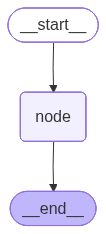

In [2]:
from typing import Optional
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from langgraph.types import interrupt,Command

class State(TypedDict):
    name:str # 姓名
    love:str # 爱好

def node(state:State):
    answer = interrupt(
        "你的爱好是什么？"
    )
    print(f"接收到前端传入的数据：{answer}")
    return {"love":answer}

# 创建图
workflow = StateGraph(State)
workflow.add_node("node",node)
workflow.set_entry_point("node")
workflow.set_finish_point("node")

# 编译图且使用内存checkpointer
graph = workflow.compile(checkpointer=InMemorySaver())
graph

运行代码，进入中断

在这里能看到一个`__interrupt__` 关键词

In [2]:
config = {
    "configurable":{
        "thread_id":1,
    }
}
for chunk in graph.stream({"name":"稳稳C9"},stream_mode=["custom","updates","values"],config=config):
    print(chunk)

('values', {'name': '稳稳C9'})
('updates', {'__interrupt__': (Interrupt(value='你的爱好是什么？', id='cec7b01cbb4542e45f59fb151c6c3bdb'),)})


我们可以查看中断时候的快照

In [10]:
stateSnapshot_list = list(graph.get_state(config))
rich.print(stateSnapshot_list)

[
    {'name': '稳稳C9'},
    ('node',),
    {
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0f2b15-5f73-6f1f-8000-351ce50195d0'
        }
    },
    {'source': 'loop', 'step': 0, 'parents': {}},
    '2026-01-16T07:59:51.388525+00:00',
    {
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0f2b15-5f6e-6934-bfff-3c2f6db35f03'
        }
    },
    (
        PregelTask(
            id='b5fdec39-16d6-c192-118b-a867f6819b85',
            name='node',
            path=('__pregel_pull', 'node'),
            error=None,
            interrupts=(Interrupt(value='你的爱好是什么？', id='cec7b01cbb4542e45f59fb151c6c3bdb'),),
            state=None,
            result=None
        ),
    ),
    (Interrupt(value='你的爱好是什么？', id='cec7b01cbb4542e45f59fb151c6c3bdb'),)
]

## 2、恢复中断

- 使用相同的config中的thread_id相同

In [11]:
command = Command(resume="骑行")
for chunk in graph.stream(command, stream_mode=["custom","updates","values"],config=config):
    print(chunk)

('values', {'name': '稳稳C9'})
接收到前端传入的数据：骑行
('updates', {'node': {'love': '骑行'}})
('values', {'name': '稳稳C9', 'love': '骑行'})


我们查看一下快照

In [12]:
stateSnapshot_list = list(graph.get_state(config))
rich.print(stateSnapshot_list)

[
    {'name': '稳稳C9', 'love': '骑行'},
    (),
    {
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0f2b1c-3a1c-6834-8001-754c6c12b417'
        }
    },
    {'source': 'loop', 'step': 1, 'parents': {}},
    '2026-01-16T08:02:55.377804+00:00',
    {
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f0f2b15-5f73-6f1f-8000-351ce50195d0'
        }
    },
    (),
    ()
]

# 二、中断常用场景

| 场景 | 意义 | 示例 |
|------|------|------|
| 🛡️ **风险控制** | 防止 AI 自动执行危险操作 | 删除数据库、转账、发送邮件 |
| 💬 **人机协作** | AI 无法独立完成，需要人类输入 | 收集订单号、验证码、用户偏好 |
| 🤔 **消除歧义** | AI 不确定时让人类做决策 | "明天"是哪天？"他"指谁？ |
| 🐛 **调试工具** | 像断点一样逐步检查流程 | 查看中间状态、验证数据 |
| ⚖️ **合规要求** | 法律规定必须人工审核 | 医疗诊断、法律建议、金融审批 |

## 1、审批工作流

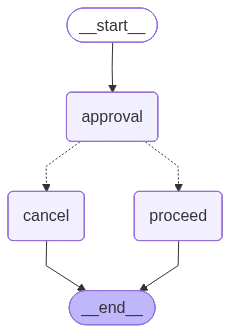

In [1]:
from typing import Literal, Optional, TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.types import Command


# 审批状态机
class ApprovalState(TypedDict):
    action_details: str # 需要审批的详情
    status: Optional[Literal["pending", "approved", "rejected"]]


# 审批节点
def approval_node(state: ApprovalState) -> Command[Literal["proceed", "cancel"]]:

    decision = interrupt({
        "question": "是否批准这个申请？",
        "details": state["action_details"],
    })

    # 通过Command的方法，恢复执行到下一个节点
    return Command(goto="proceed" if decision else "cancel")


# 批准节点
def proceed_node(state: ApprovalState):
    return {"status": "approved"}

# 拒绝节点
def cancel_node(state: ApprovalState):
    return {"status": "rejected"}

# 构建图
workflow = StateGraph(ApprovalState)
workflow.add_node("approval", approval_node)
workflow.add_node("proceed", proceed_node)
workflow.add_node("cancel", cancel_node)
workflow.set_entry_point("approval")
workflow.add_edge("proceed", END)
workflow.add_edge("cancel", END)

# 使用checkpointer编译图
checkpointer = MemorySaver()
graph = workflow.compile(checkpointer=checkpointer)
graph

运行图例

In [37]:
config = {"configurable": {"thread_id": "1"}}
initial = graph.invoke(
    {"action_details": "我需要50块买肯德基", "status": "pending"},
    config=config,
)
rich.print(initial)

{
    'action_details': '我需要50块买肯德基',
    'status': 'pending',
    '__interrupt__': [
        Interrupt(
            value={'question': '是否批准这个申请？', 'details': '我需要50块买肯德基'},
            id='9415d832000b503a75e235b6c584331e'
        )
    ]
}

我们构建的Agent，是配套我们的某个业务系统，系统弹出消息通知

财务部门相关人员，在系统收到一个需要待审批的消息

财务：
- 通过 True
- 拒绝 False

这个案例中，`Command`不单单唤醒中断的流程，并且可以根据提供决策，执行跳转到对应的`node`

In [38]:
resumed = graph.invoke(Command(resume=True), config=config)
rich.print(resumed)

{'action_details': '我需要50块买肯德基', 'status': 'approved'}

## 2、评论和编辑

我们或多都有了解深度研究报告，Agent收集用户第一波述求
- 比如生成大纲后，让用户确人是否满意，是否调整

Agent需要用户补充一些内容，以便更好的执行

In [15]:
from typing import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


class ReviewState(TypedDict):
    generated_text: str


def review_node(state: ReviewState):
    print("enter review_code")
    # 询问是否编辑这个生成的内容
    updated = interrupt({
        "instruction": "是否需要修改报告的大概？",
        "content": state["generated_text"],
    })
    return {"generated_text": updated}


builder = StateGraph(ReviewState)
builder.add_node("review", review_node)
builder.add_edge(START, "review")
builder.add_edge("review", END)

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [16]:
config = {"configurable": {"thread_id": "2"}}
initial = graph.invoke({"generated_text": "Initial draft"}, config=config)

enter review_code


In [17]:
final_state = graph.invoke(
    Command(resume="Improved draft after review"),
    config=config,
)
print(final_state["generated_text"])

enter review_code
Improved draft after review


## 3、工具中断

场景：
- 用户“帮我删除XX用户的数据”,AI识别后，选择操作数据库工具，但是执行这个工具需要人工再次同意

下面将是发送邮件的场景

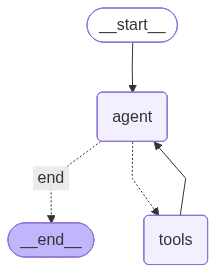

In [2]:
import sqlite3
import rich
from typing import TypedDict
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langchain_core.messages import AIMessage, ToolMessage

# ========== 1. 定义状态 ==========
class AgentState(TypedDict):
    messages: list


# ========== 2. 定义工具 ==========
@tool
def send_email(to: str, subject: str, body: str):
    """发送邮件的工具"""
    print("准备由人确认执行内容")
    response = interrupt({
        "action": "send_email",
        "to": to,
        "subject": subject,
        "body": body,
        "message": "是否需要发送该邮件？",
    })

    if response.get("action") == "approve":
        final_to = response.get("to", to)
        final_subject = response.get("subject", subject)
        final_body = response.get("body", body)
        print(f"[send_email] to={final_to} subject={final_subject} body={final_body}")
        return f"邮件已成功发送给 {final_to}"

    return "邮件已被用户取消"


# ========== 3. 创建模型并绑定工具 ==========
tools = [send_email]
tool_map = {t.name: t for t in tools}  # 工具名称到工具的映射

model = init_chat_model(model=f"openai:{modelName}")
model = model.bind_tools(tools)


# ========== 4. 定义节点 ==========
def agent_node(state: AgentState):
    """Agent 节点：调用 LLM 生成响应"""
    result = model.invoke(state["messages"])
    return {"messages": state["messages"] + [result]}


def tool_node(state: AgentState):
    """工具执行节点：执行 LLM 请求的工具调用"""
    last_message = state["messages"][-1]

    # 获取工具调用列表
    tool_calls = last_message.tool_calls
    results = []

    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        # 执行工具
        tool_func = tool_map.get(tool_name)
        if tool_func:
            result = tool_func.invoke(tool_args)
        else:
            result = f"未知工具: {tool_name}"

        # 构造 ToolMessage 返回给 LLM
        results.append(ToolMessage(
            content=str(result),
            tool_call_id=tool_id,
            name=tool_name
        ))

    return {"messages": state["messages"] + results}


# ========== 5. 定义条件路由 ==========
def should_continue(state: AgentState) -> str:
    """判断是否需要调用工具"""
    last_message = state["messages"][-1]

    # 如果 LLM 返回了 tool_calls，则执行工具
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "tools"

    # 否则结束
    return "end"


# ========== 6. 构建图 ==========
builder = StateGraph(AgentState)

# 添加节点
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

# 添加边
builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",  # 有工具调用 → 执行工具
        "end": END         # 无工具调用 → 结束
    }
)
builder.add_edge("tools", "agent")  # 工具执行完 → 回到 agent

# 编译图
checkpointer = SqliteSaver(sqlite3.connect("tool-approval.db", check_same_thread=False))
graph = builder.compile(checkpointer=checkpointer)
graph

In [3]:
config = {"configurable": {"thread_id": "email-workflow"}}
initial = graph.invoke(
    {
        "messages": [
            {"role": "user", "content": "帮我发送一封邮件给，肯德基kfc@example.com，关于疯狂星期四，我需要定10个炸鸡翅"}
        ]
    },
    config=config,
)
rich.print(initial)

准备由人确认执行内容


{
    'messages': [
        {
            'role': 'user',
            'content': '帮我发送一封邮件给，肯德基kfc@example.com，关于疯狂星期四，我需要定10个炸鸡翅'
        },
        AIMessage(
            content='用户需要发送邮件给肯德基，使用 send_email 
函数完成邮件发送，邮件主题为定10个炸鸡翅，正文说明定10个炸鸡翅相关事宜。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 130,
                    'prompt_tokens': 107,
                    'total_tokens': 237,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'doubao-1-5-pro-32k-250115',
                'system_fingerprint': None,
                'id': '02176887377439486475d51b405451fc484fdd1a9abe503d9a030',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--666c452c-5f6e-4ac9-ae01-f938b93acc37-0',
            tool_calls=[
                {
                    'name': 'send_email',
                    'args': {
                        'to': 'kfc@example.com',
                        'subject': '疯狂星期四定10个炸鸡翅',
                        'body': '你好，我想在疯狂星期四定10个炸鸡翅，谢谢！'
                    },
                    'id': 'call_546s89i6ltuxklgyysbgozhl',
                    'type': 'tool_call'
                }
            ],
            usage_metadata={
                'input_tokens': 107,
                'output_tokens': 130,
                'total_tokens': 237,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 0}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action': 'send_email',
                'to': 'kfc@example.com',
                'subject': '疯狂星期四定10个炸鸡翅',
                'body': '你好，我想在疯狂星期四定10个炸鸡翅，谢谢！',
                'message': '是否需要发送该邮件？'
            },
            id='790c125417108f5f13f01d01024326eb'
        )
    ]
}

In [7]:
initial.get("__interrupt__")

[Interrupt(value={'action': 'send_email', 'to': 'kfc@example.com', 'subject': '疯狂星期四定10个炸鸡翅', 'body': '你好，我想在疯狂星期四定10个炸鸡翅，谢谢！', 'message': '是否需要发送该邮件？'}, id='790c125417108f5f13f01d01024326eb')]

我们进行批准

In [8]:
resumed = graph.invoke(
    Command(resume={"action": "approve", "subject": "Updated subject"}),
    config=config,
)
rich.print(resumed["messages"][-1])

准备由人确认执行内容
[send_email] to=kfc@example.com subject=Updated subject body=你好，我想在疯狂星期四定10个炸鸡翅，谢谢！


AIMessage(
    content='已成功为你发送邮件给 
kfc@example.com，主题是“疯狂星期四定10个炸鸡翅”，内容为“你好，我想在疯狂星期四定10个炸鸡翅，谢谢！”。 ',
    additional_kwargs={'refusal': None},
    response_metadata={
        'token_usage': {
            'completion_tokens': 49,
            'prompt_tokens': 237,
            'total_tokens': 286,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 0,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}
        },
        'model_provider': 'openai',
        'model_name': 'doubao-1-5-pro-32k-250115',
        'system_fingerprint': None,
        'id': '021768873931052ea8ef9002080ea9c998549e6cf6a195a38dedc',
        'service_tier': 'default',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--64d99a2a-65eb-4855-ab21-77588b4f3bcd-0',
    usage_metadata={
        'input_tokens': 237,
        'output_tokens': 49,
        'total_tokens': 286,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 0}
    }
)

## 4、人机交互

```
我们模拟让Agent触发一个注册账号的Agent,用户需要填写下面3个信息，否则一直处于轮询
┌───────────────────┐
│      START        │
└─────────┬─────────┘
          │
          ▼
┌───────────────────┐
│ collect_username  │ ◄─── 验证失败则循环
└─────────┬─────────┘
          │ 验证通过
          ▼
┌───────────────────┐
│  collect_email    │ ◄─── 验证失败则循环
└─────────┬─────────┘
          │ 验证通过
          ▼
┌───────────────────┐
│  collect_phone    │ ◄─── 验证失败则循环
└─────────┬─────────┘
          │ 验证通过
          ▼
┌───────────────────┐
│       END         │
└───────────────────┘
```

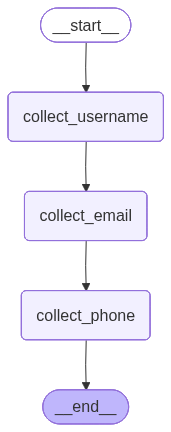

In [9]:
import sqlite3
import re
from typing import TypedDict

from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


# ========== 1. 定义状态 ==========
class RegistrationState(TypedDict):
    username: str | None
    email: str | None
    phone: str | None


# ========== 2. 验证函数 ==========
def is_valid_username(name: str) -> bool:
    """用户名：2-20个字符，只允许字母、数字、下划线、中文"""
    return bool(re.match(r'^[a-zA-Z0-9_\u4e00-\u9fa5]{2,20}$', name))


def is_valid_email(email: str) -> bool:
    """邮箱格式验证"""
    return bool(re.match(r'^[\w\.-]+@[\w\.-]+\.\w+$', email))


def is_valid_phone(phone: str) -> bool:
    """手机号：11位数字，以1开头"""
    return bool(re.match(r'^1[3-9]\d{9}$', phone))


# ========== 3. 定义节点 ==========
def collect_username_node(state: RegistrationState):
    """收集用户名"""
    prompt = "请输入您的用户名（2-20个字符，支持中文、字母、数字、下划线）："

    while True:
        answer = interrupt(prompt)

        if isinstance(answer, str) and is_valid_username(answer):
            return {"username": answer}

        prompt = f"'{answer}' 不是有效的用户名。请输入2-20个字符（支持中文、字母、数字、下划线）："


def collect_email_node(state: RegistrationState):
    """收集邮箱"""
    prompt = f"{state['username']}，请输入您的邮箱地址："

    while True:
        answer = interrupt(prompt)

        if isinstance(answer, str) and is_valid_email(answer):
            return {"email": answer}

        prompt = f"'{answer}' 不是有效的邮箱格式。请重新输入（如：example@gmail.com）："


def collect_phone_node(state: RegistrationState):
    """收集手机号"""
    prompt = "请输入您的手机号码（11位）："

    while True:
        answer = interrupt(prompt)

        if isinstance(answer, str) and is_valid_phone(answer):
            return {"phone": answer}

        prompt = f"'{answer}' 不是有效的手机号。请输入11位手机号码："


# ========== 4. 构建图 ==========
builder = StateGraph(RegistrationState)

builder.add_node("collect_username", collect_username_node)
builder.add_node("collect_email", collect_email_node)
builder.add_node("collect_phone", collect_phone_node)

builder.add_edge(START, "collect_username")
builder.add_edge("collect_username", "collect_email")
builder.add_edge("collect_email", "collect_phone")
builder.add_edge("collect_phone", END)

checkpointer = SqliteSaver(sqlite3.connect("registration.db", check_same_thread=False))
graph = builder.compile(checkpointer=checkpointer)
graph


运行代码流程，假定触发了Agent，且中

In [13]:
# ========== 5. 运行流程 ==========
config = {"configurable": {"thread_id": "registration-001"}}

# 第一步：开始注册，提示输入用户名
print("=" * 50)
print("开始注册流程")
print("=" * 50)

step1 = graph.invoke({"username": None, "email": None, "phone": None}, config=config)
print(f"提示: {step1['__interrupt__'][0].value}")

开始注册流程
提示: 请输入您的用户名（2-20个字符，支持中文、字母、数字、下划线）：


完事继续运行输入关键信息

In [14]:

# 输入无效用户名
print("\n--- 输入无效用户名 ---")
step2 = graph.invoke(Command(resume="a"), config=config)  # 太短
print(f"提示: {step2['__interrupt__'][0].value}")

# 输入有效用户名
print("\n--- 输入有效用户名 ---")
step3 = graph.invoke(Command(resume="稳稳C9"), config=config)
print(f"提示: {step3['__interrupt__'][0].value}")

# 输入无效邮箱
print("\n--- 输入无效邮箱 ---")
step4 = graph.invoke(Command(resume="not-an-email"), config=config)
print(f"提示: {step4['__interrupt__'][0].value}")

# 输入有效邮箱
print("\n--- 输入有效邮箱 ---")
step5 = graph.invoke(Command(resume="wenwenC9@example.com"), config=config)
print(f"提示: {step5['__interrupt__'][0].value}")

# 输入无效手机号
print("\n--- 输入无效手机号 ---")
step6 = graph.invoke(Command(resume="12345"), config=config)
print(f"提示: {step6['__interrupt__'][0].value}")

# 输入有效手机号，完成注册
print("\n--- 输入有效手机号 ---")
final = graph.invoke(Command(resume="13812345678"), config=config)
print("\n" + "=" * 50)
print("注册完成")
print("=" * 50)
print(f"用户名: {final['username']}")
print(f"邮箱: {final['email']}")
print(f"手机号: {final['phone']}")



--- 输入无效用户名 ---
提示: 'a' 不是有效的用户名。请输入2-20个字符（支持中文、字母、数字、下划线）：

--- 输入有效用户名 ---
提示: 稳稳C9，请输入您的邮箱地址：

--- 输入无效邮箱 ---
提示: 'not-an-email' 不是有效的邮箱格式。请重新输入（如：example@gmail.com）：

--- 输入有效邮箱 ---
提示: 请输入您的手机号码（11位）：

--- 输入无效手机号 ---
提示: '12345' 不是有效的手机号。请输入11位手机号码：

--- 输入有效手机号 ---

注册完成
用户名: 稳稳C9
邮箱: wenwenC9@example.com
手机号: 13812345678


# 三、中断使用规则

`interrupt`本质就是抛出一个异常

`interrupt`在节点中被调用，`Langgraph`就会执行暂停执行，通过异常传播堆栈，等待外部输入。

重新`resume`的时候，是从头开始运行启动`整个节点 触发interrupt那个节点`，这意味着`interrupt`之前

运行的任何代码会被再次执行

`白话文`：interrupt处理的位置需要遵守一些规则，比如，在`2.2章节`这个案例，唤醒之后也是重新执行了一次`print`

这意味着，比如某个工具断点，你将统计接口调用次数的逻辑代码放置interrupt之前是不可以的，会出现统计2次情况
- 暂停 +1
- 唤醒 +1

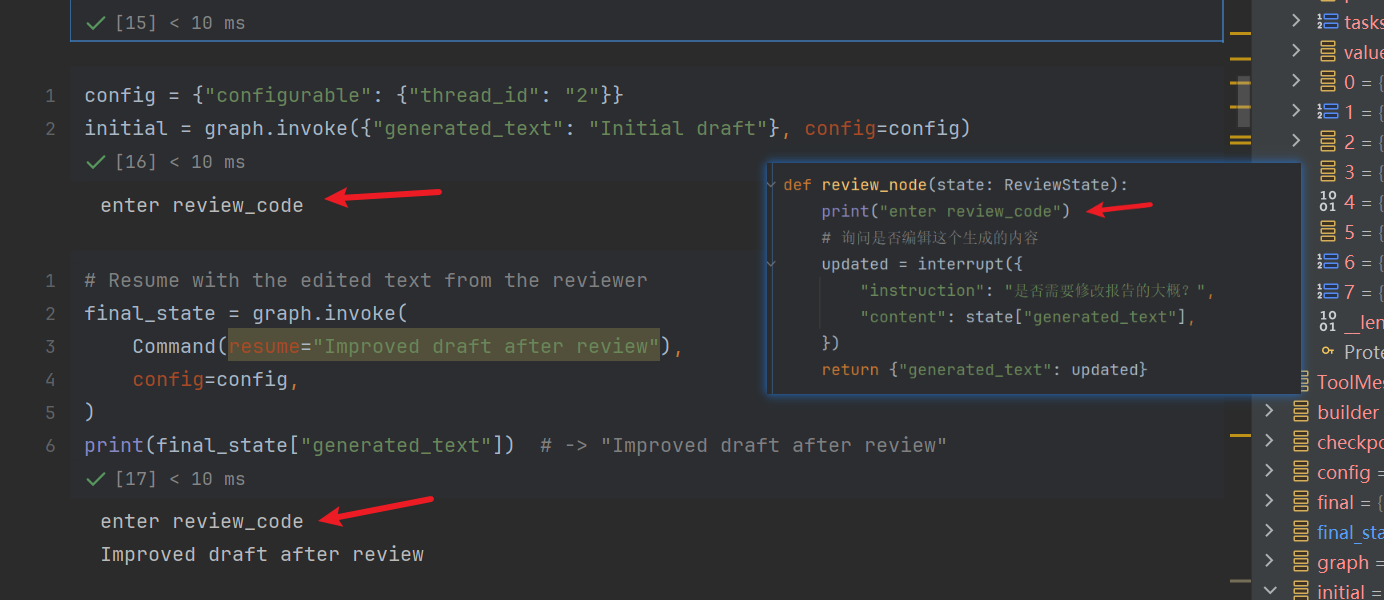

为此本节就是说明，一些我们务必注意的规则准则

## 1、在try/except注意使用interrupt的坑

### 1.1 错误示例

In [54]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt,Command

class State(TypedDict):
    action: str

llm = ChatOpenAI(model=modelName)

def etl_():
    """ 模拟报错 """
    1 / 0

def nod_a(state: State):
    """测试"""
    print("---- 进入节点 node_a")
    try:
        print("---- interrupt 之前")
        resume_body = interrupt({"action":"stop","message":"暂停中"})
        etl_() # 模拟报错代码
        print("---- interrupt 之后")
    except Exception as e:
        print("---- 抛出异常",e)
    print("---- 退出节点 node_a")
    return state


graph = (
    StateGraph(State)
    .add_node("node_a", nod_a)
    .set_entry_point("node_a")
    .set_finish_point("node_a")
    .compile(checkpointer=InMemorySaver())
)

In [55]:
res = graph.invoke({"action":"开始"},config={"configurable":{"thread_id":"t001"}})

---- 进入节点 node_a
---- interrupt 之前
---- 抛出异常 (Interrupt(value={'action': 'stop', 'message': '暂停中'}, id='e33c1c82ee8d08ccc1ad4fc96fc01091'),)
---- 退出节点 node_a


可以看到上面结果出现了明显问题，抛出异常后，被捕获跳过 且进入了`退出节点 node_a`

我们运行下面方法是拿不到`__Interrupt__`

In [56]:
res.get("__interrupt__")

### 1.2 推荐处理

容易出错的地方，进行逻辑分离，将interrupt置前

In [57]:
def nod_a(state: State):
    """测试"""
    print("---- 进入节点 node_a")
    resume_body = interrupt({"action":"stop","message":"暂停中"})
    try:
        etl_() # 模拟报错代码
    except Exception as e:
        print("---- 抛出异常",e)
    print("---- 退出节点 node_a")
    return state


graph = (
    StateGraph(State)
    .add_node("node_a", nod_a)
    .set_entry_point("node_a")
    .set_finish_point("node_a")
    .compile(checkpointer=InMemorySaver())
)
res = graph.invoke({"action":"开始"},config={"configurable":{"thread_id":"t001"}})

---- 进入节点 node_a


In [58]:
res.get("__interrupt__")

[Interrupt(value={'action': 'stop', 'message': '暂停中'}, id='1eee08dff39a8fde1bc8e22b4b112dab')]

except Exception as eexcept Exception as e如果说需要调用的业务代码，知道是什么错误类型，那么可以`显示异常处理`

不同于一刀切，不要直接使用 `Exception`
```
try:
    ...
except Exception as e:
    ...
```


In [60]:
def nod_a(state: State):
    """测试"""
    print("---- 进入节点 node_a")
    try:
        resume_body = interrupt({"action":"stop","message":"暂停中"})
        etl_() # 模拟报错代码
    except ZeroDivisionError as e:
        print("---- 抛出异常",e)
    print("---- 退出节点 node_a")
    return state


graph = (
    StateGraph(State)
    .add_node("node_a", nod_a)
    .set_entry_point("node_a")
    .set_finish_point("node_a")
    .compile(checkpointer=InMemorySaver())
)
res = graph.invoke({"action":"开始"},config={"configurable":{"thread_id":"t001"}})

---- 进入节点 node_a


In [61]:
res.get("__interrupt__")

[Interrupt(value={'action': 'stop', 'message': '暂停中'}, id='c6b296679469a49c544cbbc9405496bb')]

In [62]:
graph.invoke(Command(resume={"action":"恢复"}),config={"configurable":{"thread_id":"t001"}})

---- 进入节点 node_a
---- 抛出异常 division by zero
---- 退出节点 node_a


{'action': '开始'}

## 2、一个节点多个中断

当节点包含多个中断调用时，LangGraph 会维护一个特定于执行该节点的任务的恢复值列表。

每次执行恢复时，它都会从节点的开始处开始。对于遇到的每个中断，

LangGraph 都会检查任务的恢复列表中是否存在匹配的值。匹配严格基于索引 ，因此节点内中断调用的顺序很重要。

白话文：多个`interrupt`时候，保持顺序


### 2.1 错误示例


两种场景的 interrupt 数量和顺序不同，如果在运行过程中 state.age 的值发生变化，就会导致索引错位。

注意：任何会导致interrupt顺序发生错误的都不应该这么操作


In [74]:
class State(TypedDict):
    name:str
    age:str
    city:str

def node_a(state: State):
    # ❌ 错误做法：条件性跳过 interrupt 会改变调用顺序
    name = interrupt("What's your name?")

    # 第一次运行时，这里可能会跳过 interrupt
    # 恢复执行时，这里可能不会跳过 - 导致索引不匹配
    print("--- age：",state.get("age"))
    if state.get("age") :
        age = interrupt("What's your age?")

    city = interrupt("What's your city?")

    return {"name": name, "city": city}
res = graph.invoke({"name":"wenwenc9"},config={"configurable":{"thread_id":"t001"}})
res.get("__interrupt__")

---- 进入节点 node_a


[Interrupt(value="What's your name?", id='b235c773780bab47efa3ef0b3ee76f25')]

In [75]:
graph.invoke(Command(resume={"name":"稳稳C9"}),config={"configurable":{"thread_id":"t001"}})

---- 进入节点 node_a


{'action': '开始',
 '__interrupt__': [Interrupt(value="What's your age?", id='b235c773780bab47efa3ef0b3ee76f25')]}

明显看到逻辑错误,上面输出内容，没有看到打印，并且还是触发了，询问你的年龄是什么
```
print("--- age：",state.get("age"))
    if state.get("age") :
        age = interrupt("What's your age?")
```

另外的错误的方式

In [ ]:
def node_a(state: State):
    # ❌ 错误做法：基于不确定数据进行循环
    # interrupt 的调用次数在不同执行之间会发生变化
    results = []
    for item in state.get("dynamic_list", []):  # 列表在不同运行时可能会改变
        result = interrupt(f"Approve {item}?")
        results.append(result)

    return {"results": results}


### 2.2 推荐处理

In [64]:
def nod_a(state: State):
    """测试"""
    print("---- 进入节点 node_a")
    name = interrupt("What's your name?")
    age = interrupt("What's your age?")
    city = interrupt("What's your city?")
    print("---- 退出节点 node_a")
    return state

graph = (
    StateGraph(State)
    .add_node("node_a", nod_a)
    .set_entry_point("node_a")
    .set_finish_point("node_a")
    .compile(checkpointer=InMemorySaver())
)
res = graph.invoke({"action":"开始"},config={"configurable":{"thread_id":"t001"}})
res.get("__interrupt__")

---- 进入节点 node_a


[Interrupt(value="What's your name?", id='6a58d9b8f3fd33d818ef8f173f504793')]

## 3、不要在interrupt调用中返回复杂值


根据所使用的检查点，复杂的值可能无法序列化（例如，无法序列化函数）

正确做法
- 传递简单值，或者dict

错误做法
- 调用函数、实例化类等需要运行的操作

### 3.1 错误示例

In [ ]:
def validate_input(value):
    return len(value) > 0

def node_a(state: State):
    # ❌ 错误示例：将函数传递给 interrupt
    # 函数无法被序列化
    response = interrupt({
        "question": "What's your name?",
        "validator": validate_input  # 这会失败
    })
    return {"name": response}


class DataProcessor:
    def __init__(self, config):
        self.config = config

def node_a(state: State):
    processor = DataProcessor({"mode": "strict"})

    # ❌ 错误示例：将类实例传递给 interrupt
    # 实例对象无法被序列化
    response = interrupt({
        "question": "Enter data to process",
        "processor": processor  # 这会失败
    })
    return {"result": response}



**关键点说明：**

- **序列化问题**：`interrupt()` 需要将数据持久化存储，只能接受可序列化的数据类型（如字符串、数字、字典、列表等）
- **不可序列化的类型**：
  - 函数对象（如 `validate_input`）
  - 类实例（如 `processor`）
  - Lambda 表达式
  - 文件句柄等

**正确做法**：只传递基本数据类型，在恢复后重新创建函数或实例。

### 3.2 推荐处理

In [ ]:
def node_a(state: State):
    # ✅ 正确示例：传递可序列化的简单类型
    name = interrupt("What's your name?")
    count = interrupt(42)
    approved = interrupt(True)

    return {"name": name, "count": count, "approved": approved}

def node_a(state: State):
    # ✅ 正确示例：传递包含简单值的字典
    response = interrupt({
        "question": "Enter user details",
        "fields": ["name", "email", "age"],
        "current_values": state.get("user", {})
    })

    return {"user": response}


## 4、幂等操作

中断通过重新运行它们被调用的节点来工作

当使用 interrupt() 时，节点会被暂停，等待外部输入后重新执行。这意味着 interrupt() 之前的代码可能会被执行多次


**常见的幂等 vs 非幂等操作**

**幂等操作：**
- 数据库：SELECT 查询
- 文件：读取文件
- 计数器：读取值
- API：GET 请求
- 状态：读取 state["x"]

**非幂等操作：**
- 数据库：INSERT 插入（无检查）
- 文件：追加写入文件
- 计数器：counter += 1
- API：POST 创建订单
- 状态：修改 state["x"] = y


### 4.1 错误示例

如果节点重新运行，余额会被重复增加（100 → 200 → 300...）

In [ ]:
def node_a(state: State):
    # 每次执行都会增加余额
    state["balance"] += 100  # 警告：重新运行时会重复增加

    # 中断等待确认
    confirmed = interrupt("Confirm transaction?")

    if confirmed:
        return {"balance": state["balance"]}


### 4.2 推荐处理

无论重新运行多少次，计算结果都一样

In [ ]:
def node_a(state: State):
    # 只是读取或计算，不修改状态
    proposed_amount = 100
    new_balance = state["balance"] + proposed_amount  # 只是计算

    # 中断等待确认
    confirmed = interrupt(f"Add {proposed_amount} to balance?")

    if confirmed:
        # 只在确认后才修改
        return {"balance": new_balance}


一般来说，将有副作用的代码放到中断之后

In [ ]:
def node_a(state: State):
    # interrupt 之前：只读取和计算
    user_id = state.get("user_id")
    order_data = prepare_order(state["items"])  # 纯计算

    # 中断点
    approved = interrupt({
        "order": order_data,
        "question": "Confirm order?"
    })

    # interrupt 之后：执行副作用
    if approved:
        order_id = create_order_in_db(order_data)  # 实际写入
        send_email(user_id, order_id)  # 发送邮件
        return {"order_id": order_id}

# 四、在子图中中断


一句话，父图调用子图的节点会重执行一次，子图出现中断节点的也会重新执行一次


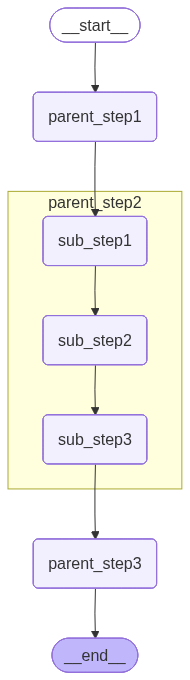

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt
from typing import TypedDict

# 定义状态
class State(TypedDict):
    step: str
    user_name: str
    user_age: int
    final_message: str

# ==================== 子图：3个节点 ====================

def subgraph_step1(state: State):
    """子图节点1：准备问题"""
    print("  [子图-节点1] 准备收集用户信息")
    return {"step": "子图节点1完成"}

def subgraph_step2(state: State):
    """子图节点2：询问用户（中断点）"""
    print("  [子图-节点2] 开始询问用户姓名...")  # <-- 恢复时会重新执行

    # 中断：等待用户输入
    name = interrupt("请输入你的姓名：")

    print(f"  [子图-节点2] 收到姓名：{name}")
    return {"user_name": name, "step": "子图节点2完成"}

def subgraph_step3(state: State):
    """子图节点3：处理结果"""
    print(f"  [子图-节点3] 处理用户信息：{state['user_name']}")
    return {"step": "子图节点3完成"}

# 构建子图
subgraph_builder = StateGraph(State)
subgraph_builder.add_node("sub_step1", subgraph_step1)
subgraph_builder.add_node("sub_step2", subgraph_step2)  # 包含中断
subgraph_builder.add_node("sub_step3", subgraph_step3)

subgraph_builder.add_edge(START, "sub_step1")
subgraph_builder.add_edge("sub_step1", "sub_step2")
subgraph_builder.add_edge("sub_step2", "sub_step3")
subgraph_builder.add_edge("sub_step3", END)

subgraph = subgraph_builder.compile()

# ==================== 父图：3个节点 ====================

def parent_step1(state: State):
    """父图节点1：初始化"""
    print("[父图-节点1] 开始流程")
    return {"step": "父图节点1完成"}

def parent_step2(state: State):
    """父图节点2：调用子图"""
    print("[父图-节点2] 准备调用子图...")  # <-- 恢复时会重新执行

    # 调用子图（子图中有中断）
    subgraph_result = subgraph.invoke(state)

    print("[父图-节点2] 子图执行完毕")
    return {
        "user_name": subgraph_result.get("user_name", ""),
        "step": "父图节点2完成"
    }

def parent_step3(state: State):
    """父图节点3：生成最终结果"""
    print(f"[父图-节点3] 生成最终消息")
    message = f"欢迎 {state['user_name']} 使用系统！"
    return {"final_message": message, "step": "父图节点3完成"}

# 构建父图
parent_builder = StateGraph(State)
parent_builder.add_node("parent_step1", parent_step1)
parent_builder.add_node("parent_step2", parent_step2)  # 调用子图
parent_builder.add_node("parent_step3", parent_step3)

parent_builder.add_edge(START, "parent_step1")
parent_builder.add_edge("parent_step1", "parent_step2")
parent_builder.add_edge("parent_step2", "parent_step3")
parent_builder.add_edge("parent_step3", END)

# 编译父图
memory = MemorySaver()
parent_graph = parent_builder.compile(checkpointer=memory)
from IPython.display import Image, display
display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))  # 可能会超时，需要开启代理

In [80]:
config = {"configurable": {"thread_id": "demo_001"}}
initial_state = {
    "step": "",
    "user_name": "",
    "user_age": 0,
    "final_message": ""
}

第一次运行，执行到断点

In [82]:
result1 = parent_graph.invoke(initial_state, config)
result1.get("__interrupt__")

[父图-节点1] 开始流程
[父图-节点2] 准备调用子图...
  [子图-节点1] 准备收集用户信息
  [子图-节点2] 开始询问用户姓名...


[Interrupt(value='请输入你的姓名：', id='5fe03df0834347f517ad4276b4530f88')]

模拟用户输入

In [83]:
result2 = parent_graph.invoke(Command(resume="稳稳C9"),config)

[父图-节点2] 准备调用子图...
  [子图-节点2] 开始询问用户姓名...
  [子图-节点2] 收到姓名：稳稳C9
  [子图-节点3] 处理用户信息：稳稳C9
[父图-节点2] 子图执行完毕
[父图-节点3] 生成最终消息




```css
首次运行（遇到中断）：
┌─────────────────────────────────────────┐
│ 父图-节点1：初始化                        │
└─────────────────────────────────────────┘
              ↓
┌─────────────────────────────────────────┐
│ 父图-节点2：准备调用子图...               │ ← 会重新执行
└─────────────────────────────────────────┘
              ↓
    ┌─────────────────────────┐
    │ 子图-节点1：准备问题      │
    └─────────────────────────┘
              ↓
    ┌─────────────────────────┐
    │ 子图-节点2：开始询问...   │ ← 会重新执行
    │ [中断：等待输入]          │ ← 暂停在这里
    └─────────────────────────┘

恢复运行（提供输入后）：
┌─────────────────────────────────────────┐
│ 父图-节点2：准备调用子图...               │ ← 重新执行
└─────────────────────────────────────────┘
              ↓
    ┌─────────────────────────┐
    │ 子图-节点2：开始询问...   │ ← 重新执行
    │ [收到输入：稳稳C9]          │
    │ 收到姓名：稳稳C9            │
    └─────────────────────────┘
              ↓
    ┌─────────────────────────┐
    │ 子图-节点3：处理用户信息  │ ← 首次执行
    └─────────────────────────┘
              ↓
┌─────────────────────────────────────────┐
│ 父图-节点2：子图执行完毕                  │
└─────────────────────────────────────────┘
              ↓
┌─────────────────────────────────────────┐
│ 父图-节点3：生成最终消息                  │ ← 首次执行
└─────────────────────────────────────────┘

```

# 五、静态中断

In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from typing import TypedDict

# 定义状态
class State(TypedDict):
    message: str
    step: str

# ==================== 定义3个节点 ====================

def node_a(state: State):
    """节点A：数据准备"""
    print("[节点A] 准备数据...")
    return {"message": "数据已准备", "step": "A完成"}

def node_b(state: State):
    """节点B：数据处理"""
    print("[节点B] 处理数据...")
    return {"message": "数据已处理", "step": "B完成"}

def node_c(state: State):
    """节点C：数据保存"""
    print("[节点C] 保存数据...")
    return {"message": "数据已保存", "step": "C完成"}

# ==================== 构建图 ====================

builder = StateGraph(State)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", "node_c")
builder.add_edge("node_c", END)


## 1、编译时设置静态中断

 一般用于调试的时候

In [3]:
checkpointer = MemorySaver()

# 在编译时设置中断点
graph = builder.compile(
    interrupt_before=["node_a"],           # 在 node_a 执行前中断
    interrupt_after=["node_b", "node_c"],  # 在 node_b 和 node_c 执行后中断
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": "thread_001"}}
initial_state = {"message": "开始", "step": "初始"}

# 第1次运行：会在 node_a 之前停止
print("\n[运行1] 启动图...")
result1 = graph.invoke(initial_state, config=config)
print(f"当前状态：{result1}")
print("→ 在 node_a 之前暂停\n")

# 第2次运行：执行 node_a，然后在 node_b 之后停止
print("[运行2] 继续执行...")
result2 = graph.invoke(None, config=config)
print(f"当前状态：{result2}")
print("→ node_a 已执行，node_b 已执行，在 node_b 之后暂停\n")

# 第3次运行：执行 node_c，然后在 node_c 之后停止
print("[运行3] 继续执行...")
result3 = graph.invoke(None, config=config)
print(f"当前状态：{result3}")
print("→ node_c 已执行，在 node_c 之后暂停\n")

# 第4次运行：完成整个流程
print("[运行4] 继续执行...")
result4 = graph.invoke(None, config=config)
print(f"最终状态：{result4}")
print("→ 流程完成\n")


[运行1] 启动图...
当前状态：{'message': '开始', 'step': '初始'}
→ 在 node_a 之前暂停

[运行2] 继续执行...
[节点A] 准备数据...
[节点B] 处理数据...
当前状态：{'message': '数据已处理', 'step': 'B完成'}
→ node_a 已执行，node_b 已执行，在 node_b 之后暂停

[运行3] 继续执行...
[节点C] 保存数据...
当前状态：{'message': '数据已保存', 'step': 'C完成'}
→ node_c 已执行，在 node_c 之后暂停

[运行4] 继续执行...
最终状态：{'message': '数据已保存', 'step': 'C完成'}
→ 流程完成



## 2、运行时设置静态中断

更加灵活，用于生产都没有问题

In [4]:
# 重新编译图（不设置静态中断）
graph2 = builder.compile(checkpointer=MemorySaver())

config2 = {"configurable": {"thread_id": "thread_002"}}

# 在运行时指定中断点
print("\n[运行1] 启动图，设置中断点...")
result1 = graph2.invoke(
    initial_state,
    interrupt_before=["node_a"],           # 运行时指定
    interrupt_after=["node_b", "node_c"],  # 运行时指定
    config=config2,
)
print(f"当前状态：{result1}")
print("→ 在 node_a 之前暂停\n")

# 后续运行不需要再指定中断点
print("[运行2] 继续执行...")
result2 = graph2.invoke(None, config=config2)
print(f"当前状态：{result2}")
print("→ 在 node_b 之后暂停\n")

print("[运行3] 继续执行...")
result3 = graph2.invoke(None, config=config2)
print(f"当前状态：{result3}")
print("→ 在 node_c 之后暂停\n")

print("[运行4] 继续执行...")
result4 = graph2.invoke(None, config=config2)
print(f"最终状态：{result4}")
print("→ 流程完成\n")


[运行1] 启动图，设置中断点...
当前状态：{'message': '开始', 'step': '初始'}
→ 在 node_a 之前暂停

[运行2] 继续执行...
[节点A] 准备数据...
[节点B] 处理数据...
[节点C] 保存数据...
当前状态：{'message': '数据已保存', 'step': 'C完成'}
→ 在 node_b 之后暂停

[运行3] 继续执行...
当前状态：{'message': '数据已保存', 'step': 'C完成'}
→ 在 node_c 之后暂停

[运行4] 继续执行...
最终状态：{'message': '数据已保存', 'step': 'C完成'}
→ 流程完成



## 3、与动态中断区别


| 特性 | 静态中断 | 动态中断 (interrupt函数) |
|------|---------|------------------------|
| 设置位置 | 编译时或运行时 | 代码中调用 |
| 用途 | 调试、测试 | 人机交互 |
| 灵活性 | 固定位置 | 动态条件 |
| 推荐场景 | 开发调试 | 生产环境 |